# Naive RAG1 - Chat with your text document

- R - Retrieval , A - Augmented , G - Generation = a framework that combines retrieval based systems and generation based models to produce more accurate and contextual relevant response.
- Train with your own documents and chat with them. The general flow of LLM

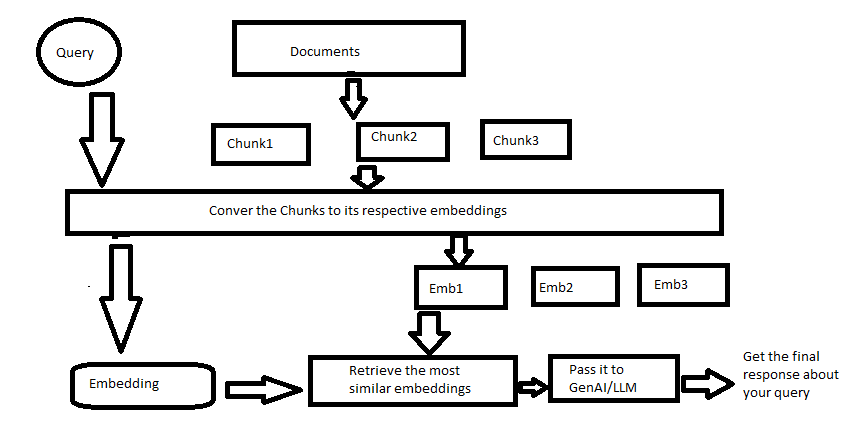

In [116]:
# Import os library
import os 

# Import chromadb for embedding 
from chromadb.utils import embedding_functions
import chromadb

# Import openai for converting embeddings, that is chat completions
from openai import AzureOpenAI

In [117]:
# Credentials to access Azure OPENAI 
endpoint = os.getenv("ENDPOINT_URL", "<FILL_AZURE_ENDPOINT_URL>")
deployment = os.getenv("DEPLOYMENT_NAME", "<FILL_MODEL_DEPLOYMENT_NAME>")
subscription_key = os.getenv("AZURE_OPENAI_API_KEY", "<FILL_AZURE_OPENAI_KEY>")

# Initialize Azure OpenAI client with key-based authentication
client = AzureOpenAI(
    azure_endpoint = endpoint,
    api_key = subscription_key,
    api_version = "2024-05-01-preview",
)

In [118]:
# Initialize ChromaDB client with OpenAI embedding function
embedding_function = embedding_functions.OpenAIEmbeddingFunction(
    api_key = subscription_key,
    model_name = "text-embedding-ada-002",
    api_base=endpoint,
    api_type="azure",
    api_version="2023-05-15"
)

In [119]:
# Initializing chroma client with persistence
# Initialize the vectordb to store the embeddings of the document 

chroma_client = chromadb.PersistentClient(path="chroma_persistent_storage")
collection = chroma_client.get_or_create_collection(name="chroma_collection",embedding_function=embedding_function)

In [120]:
# Initialize the chat completion for the embeddings using openai gpt

completion = client.chat.completions.create(
    model=deployment,
    messages= [
    {
        "role": "system",
        "content": "You are an AI assistant that helps people find information."
    },
    {
        "role":"user",
        "content":"What is role of Appian ?"
    }
],
    max_tokens=800,
    temperature=0.7,
    top_p=0.95,
    frequency_penalty=0,
    presence_penalty=0,
    stop=None,
    stream=False
)
print(completion.choices[0].message.content)

Appian is a low-code platform for building enterprise software applications. It allows users to design, build, and deploy custom applications quickly and easily, without needing extensive coding skills. The platform provides tools for process management, data integration, mobile access, and collaboration. Appian enables organizations to automate business processes, improve customer engagement, and gain operational insights through data analytics. It is used by businesses in a variety of industries, including finance, healthcare, manufacturing, and government.


In [121]:
# Function to load documents from directory from the directory path

def load_documents_from_directory(directory_path):
    documents = []
    for filename in os.listdir(directory_path):
        file_path = os.path.join(directory_path, filename)
        if os.path.isfile(file_path):
            with open(file_path, 'r', encoding='utf-8') as file:
                documents.append({"id":filename,"text":file.read()})
    return documents

# Split the documents into chunks of 1000 characters each, with an overlap of 20 characters between chunks
# Overlap shows the contextual meaning of each text is at distance of 20 which is context is kept

def split_text(text, chunk_size=1000, overlap=20):
    chunks = []
    start=0
    while start<len(text):
        end=start+chunk_size
        chunks.append(text[start:end])
        start=end-overlap 
    return chunks


In [122]:
# Load documents from directory 
directory_path="./sample_docs"
documents=load_documents_from_directory(directory_path)
chunked_documents=[]

# Call split_text function to split the texts in chunks
for doc in documents:
    chunks=split_text(doc["text"])
    for i, chunk in enumerate(chunks):
        chunked_documents.append({"id":f"{doc['id']}_chunk{i+1}","text":doc["text"]})
print(len(chunked_documents))

1


In [123]:
# As now we splitted the text into chunks, now based on the flow its time to convert the chunks into embeddings


def get_openai_embeddings(text):
    response=client.embeddings.create(input=text,model="text-embedding-ada-002")
    embedding=response.data[0].embedding
    print("=== Generating the embeddings for text... ===")
    return embedding

# Generate embedding for each chunk

for doc in chunked_documents:
    print("=== Generating the embeddings for each chunk... ===")
    doc["embedding"]=get_openai_embeddings(doc["text"])


=== Generating the embeddings for each chunk... ===
=== Generating the embeddings for text... ===


In [124]:
# Upsert the documents with embeddings into Chromadb that is VECTOR STORE.

for doc in chunked_documents:
    print("Upserting documents into Chromadb...")
    collection.upsert(
        ids=[doc["id"]],
        documents=[doc["text"]],
        embeddings=[doc["embedding"]]
    )

Upserting documents into Chromadb...


In [125]:
# Function to query documents and return the mention amount of results

def query_documents(question,n_results=2):
    results=collection.query(
        query_texts=[question],
        n_results=n_results
    )
    print(results)
    relevant_chunks=[doc for sublist in results["documents"] for doc in sublist]
    print("=== Returning relevant chunks ===")
    for idx,document in enumerate(results["documents"]):
        doc_id=results["ids"][0][idx]
        distance=results["distances"][0][idx]
        print(f"Found document chunk: {document} with ID: {doc_id} and distance: {distance}")
    return relevant_chunks

In [128]:
# Function to generate response from openai

def generate_response(question,relevant_chunks):
    context="\n\n".join(relevant_chunks)
    prompt=f"You are an assistant for question-answering. For user question retrieve relevant information from the context. Context: {context}\n\nQuestion: {question}\nAnswer: "
    response=client.chat.completions.create(
       model="gpt-35-turbo",
       messages=[{"role":"system","content":prompt},{"role":"user","content":question}]
    )
    answer=response.choices[0].message
    return answer

In [132]:


question="Is there any person called Nirobi mentioned ?"
relevant_chunks=query_documents(question)
answer=generate_response(question,relevant_chunks)
print(answer)

Number of requested results 2 is greater than number of elements in index 1, updating n_results = 1


{'ids': [['personal_favorite.txt_chunk1']], 'distances': [[0.5533633011499131]], 'metadatas': [[None]], 'embeddings': None, 'documents': [["Hey I am Jacksparrow\nThey call me as captain Jacksparrow\nI like to travel by ship and it's name is Black pearl\nMy real name is Jhonny Depp"]], 'uris': None, 'data': None, 'included': ['metadatas', 'documents', 'distances']}
=== Returning relevant chunks ===
Found document chunk: ["Hey I am Jacksparrow\nThey call me as captain Jacksparrow\nI like to travel by ship and it's name is Black pearl\nMy real name is Jhonny Depp"] with ID: personal_favorite.txt_chunk1 and distance: 0.5533633011499131
ChatCompletionMessage(content='No, there is no person called Nirobi mentioned in the provided context.', refusal=None, role='assistant', function_call=None, tool_calls=None)


### NAIVE RAG - Full flow for reference

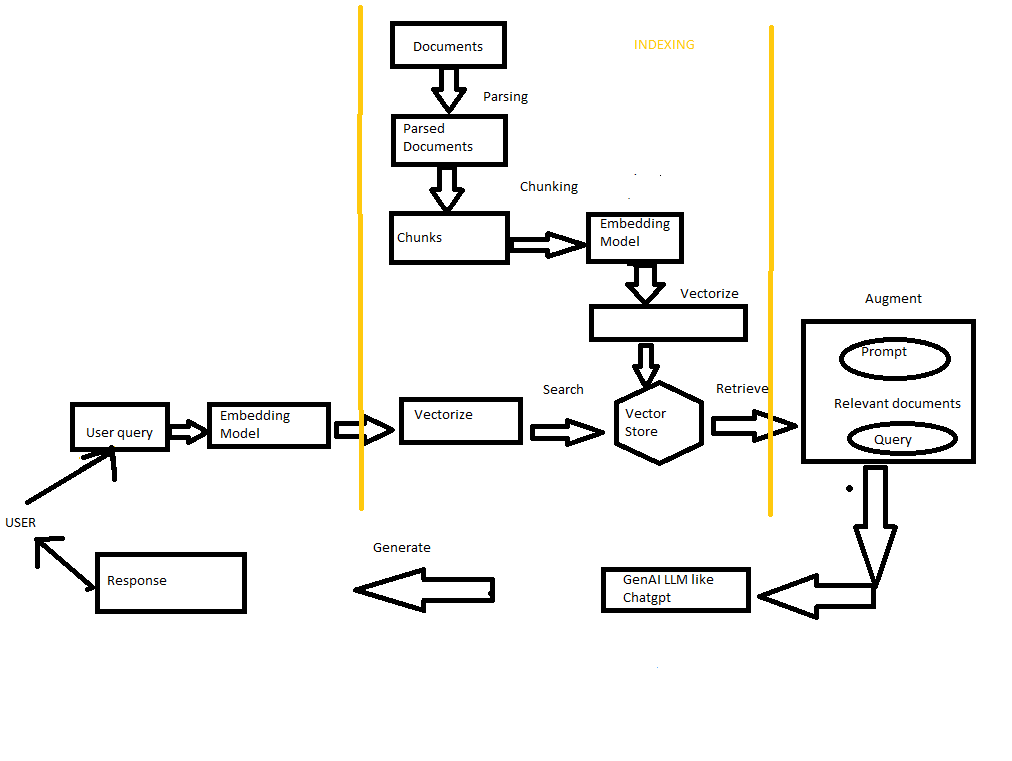

**Pitfalls**

- Limited contextual understanding - Focus on keyword matching/basic semantic search i.e., retrieves irrleevant o partially relevant docs
- Inconsistent relevance and quality of retrieved documents - Varying quality and relevance documents (poor-quality inputs for gen model)
- Poor integration between retrieval and generation - Retriever and generator not work together maybe we get off topic answers
- Inefficient handling of large scale data - May take too long to find relevant docs and miss critical info due to bad indexing.
- Lack of robustness and adaptability - not adaptable to changing context or user needs without manual intervention.